# 07. Model Comparison

Aggregates results from all previously trained models and visualizes their performance.

Found 6 metric files: ['../results/metrics/logistic_regression/logistic_regression.json', '../results/metrics/xgboost/xgboost.json', '../results/metrics/transformer/transformer_metrics.json', '../results/metrics/uplift/metrics.json', '../results/metrics/gru/gru_metrics.json', '../results/metrics/lightgbm/lightgbm.json']


,model,accuracy,roc_auc,pr_auc,brier,ate,segmentation,description,ate_conf_interval,best_params
0,Logistic Regression,0.650602,0.683636,0.769032,0.229313,NaN,NaN,NaN,NaN,NaN
1,XGBoost,0.638554,0.670909,0.771540,0.241611,NaN,NaN,NaN,NaN,NaN
2,Transformer,0.698795,0.714545,0.724557,0.211482,NaN,NaN,NaN,NaN,NaN
3,Causal Uplift,0.759036,0.796970,0.835597,0.191987,-0.201584,"{'Lost Cause': 0.7228915662650602, 'Sleeping D...",Final Causal Uplift Model Analysis,"[-0.316433478089681, -0.0867336848217155]",NaN
4,LSTM/GRU,0.674699,0.730303,0.756500,0.214468,NaN,NaN,NaN,NaN,NaN
5,LightGBM,0.759036,0.796970,0.839207,0.191987,NaN,NaN,NaN,NaN,"{'n_estimators': 183, 'max_depth': 9, 'learnin..."


 Saved comparison plot


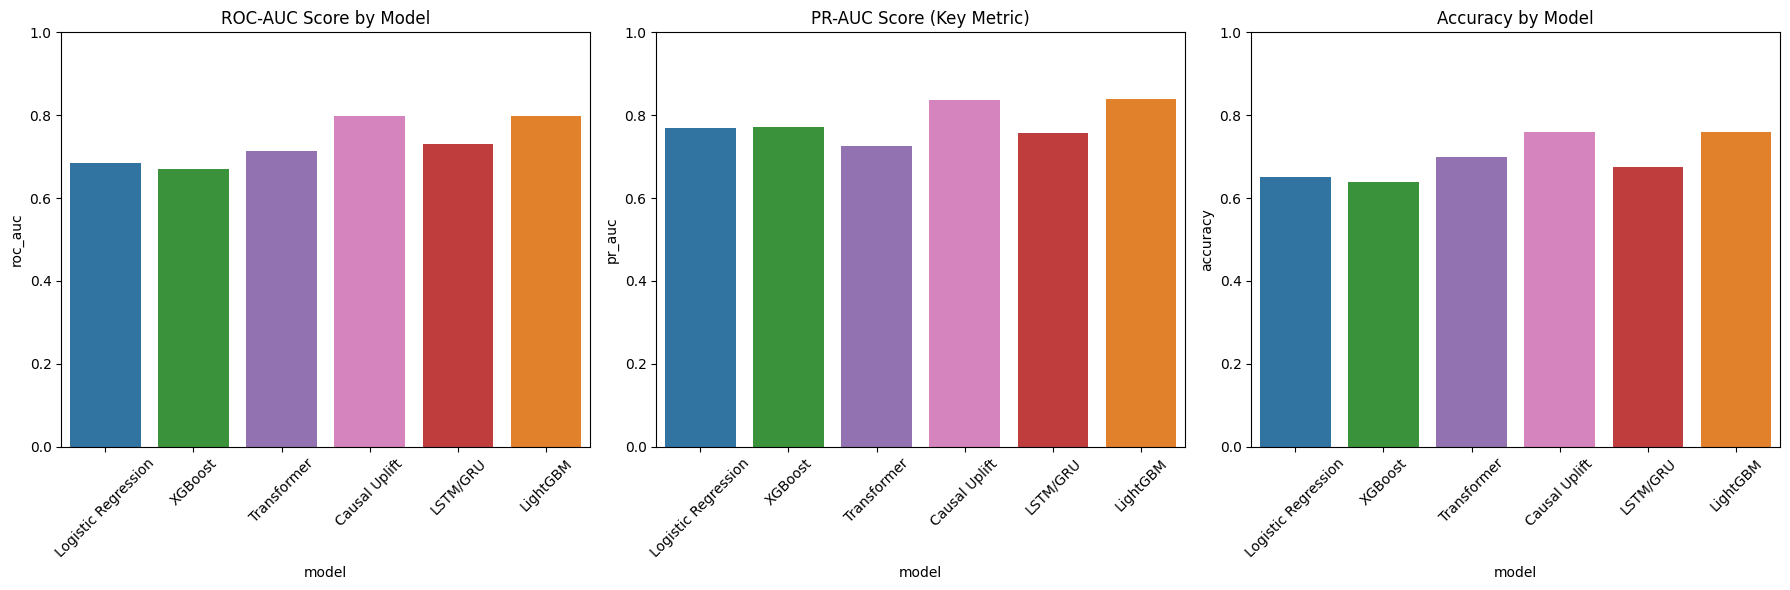

In [1]:
import json
import os
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import glob

import warnings
warnings.filterwarnings("ignore")


# Robustly find all json files in recursive subdirectories
metrics_dir = '../results/metrics'
metric_files = glob.glob(os.path.join(metrics_dir, '**/*.json'), recursive=True)

print(f"Found {len(metric_files)} metric files: {metric_files}")

results = []
for f in metric_files:
    try:
        with open(f, 'r') as file:
            results.append(json.load(file))
    except Exception as e:
        print(f"Error loading {f}: {e}")

if not results:
    print("Warning: No metrics loaded.")
    df_res = pd.DataFrame(columns=['model', 'roc_auc', 'pr_auc', 'accuracy'])
else:
    df_res = pd.DataFrame(results)

display(df_res)

# Consistent Colors
color_map = {
    'Logistic Regression': '#1f77b4',
    'XGBoost': '#2ca02c',
    'LightGBM': '#ff7f0e',
    'LSTM/GRU': '#d62728',
    'Transformer': '#9467bd',
    'Causal Uplift': '#e377c2'
}

# Only proceed if we have data
if not df_res.empty and 'model' in df_res.columns:
    palette = [color_map.get(m, '#333333') for m in df_res['model']]

    # Plotting
    fig, axes = plt.subplots(1, 3, figsize=(18, 6))

    # ROC-AUC
    if 'roc_auc' in df_res.columns:
        sns.barplot(data=df_res, x='model', y='roc_auc', palette=color_map, ax=axes[0])
        axes[0].set_title('ROC-AUC Score by Model')
        axes[0].set_ylim(0, 1.0)
        axes[0].tick_params(axis='x', rotation=45)

    # PR-AUC
    if 'pr_auc' in df_res.columns:
        sns.barplot(data=df_res, x='model', y='pr_auc', palette=color_map, ax=axes[1])
        axes[1].set_title('PR-AUC Score (Key Metric)')
        axes[1].set_ylim(0, 1.0)
        axes[1].tick_params(axis='x', rotation=45)

    # Accuracy
    if 'accuracy' in df_res.columns:
        sns.barplot(data=df_res, x='model', y='accuracy', palette=color_map, ax=axes[2])
        axes[2].set_title('Accuracy by Model')
        axes[2].set_ylim(0, 1.0)
        axes[2].tick_params(axis='x', rotation=45)

    plt.tight_layout()
    plt.savefig('../results/figures/comparison/model_comparison.png')
    print(' Saved comparison plot')
    plt.show()
else:
    print(" No valid data to plot.")

In [2]:
#

In [3]:
# === Causal Uplift Model Results ===
# The Uplift Model is evaluated differently (ATE/CATE) than predictive models (AUC/Accuracy).
try:
    with open('../results/metrics/uplift/metrics.json', 'r') as f:
        uplift_metrics = json.load(f)
    
    print("\n" + "="*40)
    print(" Causal Uplift Model Insights")
    print("="*40)
    print(f"Average Treatment Effect (ATE): {uplift_metrics['ate']:.1%} reduction in churn probability")
    if 'ate_conf_interval' in uplift_metrics:
        ci = uplift_metrics['ate_conf_interval']
        print(f"95% Confidence Interval: [{ci[0]:.1%}, {ci[1]:.1%}]")
    
    print("\nUser Segmentation:")
    for segment, ratio in uplift_metrics['segmentation'].items():
        print(f"  - {segment}: {ratio:.1%}")
        
    print(f"\nDescription: {uplift_metrics['description']}")
    print("="*40 + "\n")
except Exception as e:
    print(f"Could not load Uplift metrics: {e}")



 Causal Uplift Model Insights
Average Treatment Effect (ATE): -20.2% reduction in churn probability
95% Confidence Interval: [-31.6%, -8.7%]

User Segmentation:
  - Lost Cause: 72.3%
  - Sleeping Dog: 14.5%
  - Do-not-disturb: 12.0%
  - Persuadable: 1.2%

Description: Final Causal Uplift Model Analysis

